
Event: campaign_start
                            OLS Regression Results                            
Dep. Variable:             log_volume   R-squared:                       0.709
Model:                            OLS   Adj. R-squared:                  0.700
Method:                 Least Squares   F-statistic:                     89.79
Date:                Fri, 22 May 2026   Prob (F-statistic):               0.00
Time:                        16:20:03   Log-Likelihood:                -28415.
No. Observations:               23552   AIC:                         5.827e+04
Df Residuals:                   22832   BIC:                         6.408e+04
Df Model:                         719                                         
Covariance Type:                  HC3                                         
                                          coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------

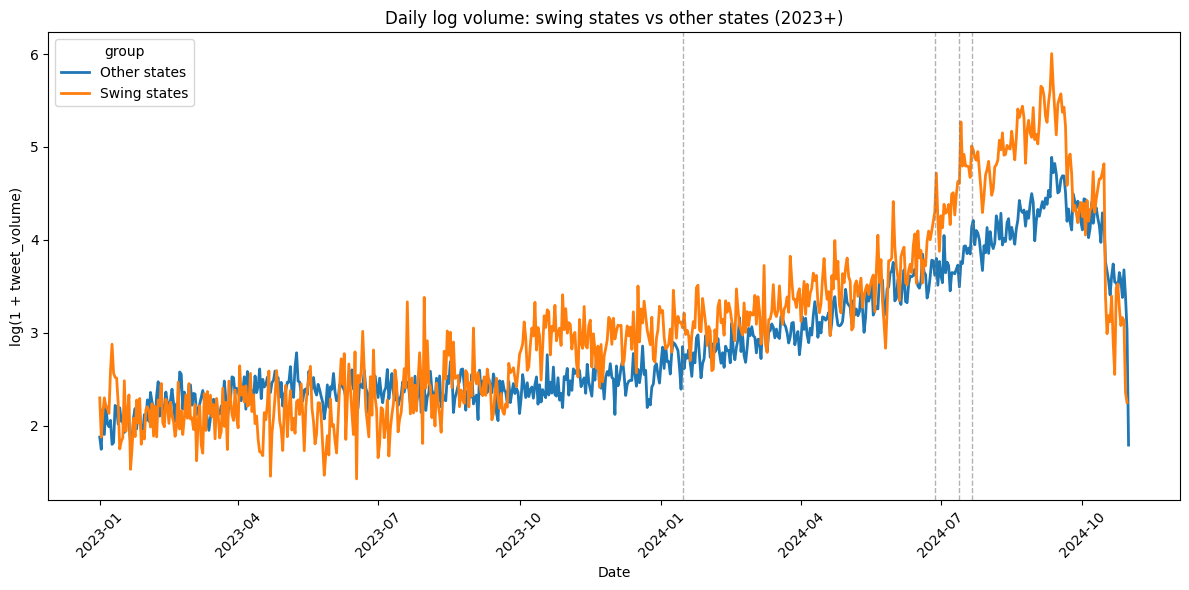


Data range: 2023-01-01 to 2024-10-31
Panel: 23,552 state-days, 50 states


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# ================================
# 1. LOAD DATA
# ================================
file_path = r"E:\Csci_3\subjects_AND_sampling_metadata_anonymized_full.csv"

df = pd.read_csv(
    file_path,
    usecols=[
        "created_at",
        "tweets_historical",
        "clean...state_simple",
        "in_reply_to_user_id_code",
    ],
    dtype={
        "clean...state_simple": "string",
        "in_reply_to_user_id_code": "string",
    },
    low_memory=False,
)

# ================================
# 2. CLEAN
# ================================
df = df.dropna(subset=["created_at", "clean...state_simple"])

# Parse UTC timestamps and collapse to calendar days (not raw timestamps)
df["date"] = pd.to_datetime(df["created_at"], errors="coerce", utc=True).dt.normalize()
df = df.dropna(subset=["date"])

df.rename(columns={"clean...state_simple": "state"}, inplace=True)

# Restrict to the election cycle window so pre-2024 noise does not dominate
analysis_start = pd.Timestamp("2023-01-01", tz="UTC")
df = df[df["date"] >= analysis_start].copy()

# ================================
# 3. TREATMENT: SWING STATES VS ALL OTHERS
# ================================
swing_states = [
    "Arizona", "Georgia", "Michigan",
    "Nevada", "North Carolina",
    "Pennsylvania", "Wisconsin",
]

df["treated"] = df["state"].isin(swing_states).astype(int)

# ================================
# 4. DAILY AGGREGATION (STATE x CALENDAR DAY)
# ================================
# tweets_historical holds tweet text; count = sampled subjects per state-day
daily = df.groupby(["state", "date"], as_index=False).agg(
    tweet_volume=("tweets_historical", "count"),
    reply_volume=("in_reply_to_user_id_code", lambda x: x.notna().sum()),
    treated=("treated", "max"),
)

daily["log_volume"] = np.log1p(daily["tweet_volume"])
# Use plain str labels for formula API compatibility (not pandas StringDtype)
daily["state_id"] = daily["state"].astype(str)
daily["date_id"] = daily["date"].dt.strftime("%Y-%m-%d")

# ================================
# 5. EVENT DEFINITIONS
# ================================
events = {
    "campaign_start": "2024-01-15",
    "debate": "2024-06-27",
    "trump_incident": "2024-07-13",
    "biden_dropout": "2024-07-21",
    # election_day omitted: data ends 2024-10-31, no post-window coverage
}

data_end = daily["date"].max()

# ================================
# 6. EVENT WINDOWS (LEAD / POST RELATIVE TO EACH EVENT)
# ================================
for event_name, event_date in events.items():
    event_dt = pd.to_datetime(event_date, utc=True)
    daily[f"{event_name}_time"] = (daily["date"] - event_dt).dt.days

    daily[f"{event_name}_lead"] = (
        (daily[f"{event_name}_time"] >= -10) & (daily[f"{event_name}_time"] <= -1)
    ).astype(int)
    daily[f"{event_name}_post"] = (
        (daily[f"{event_name}_time"] >= 0) & (daily[f"{event_name}_time"] <= 10)
    ).astype(int)
    daily[f"{event_name}_did"] = daily["treated"] * daily[f"{event_name}_post"]

# ================================
# 7. DIFFERENCE-IN-DIFFERENCES (ONE EVENT PER MODEL)
# ================================
# State FE absorbs time-invariant treated; date FE absorbs national shocks.
# Do not include a separate 'treated' level term (collinear with C(state_id)).
# Estimate events separately to avoid overlapping post-window collinearity.

def run_event_did(data, event_name):
    """OLS DiD for a single event with state and calendar-day fixed effects."""
    did_col = f"{event_name}_did"
    post_col = f"{event_name}_post"

    if data[post_col].sum() == 0:
        return None

    formula = f"log_volume ~ {did_col} + C(state_id) + C(date_id)"
    return smf.ols(formula, data=data).fit(cov_type="HC3")


results = []
for event_name in events:
    model = run_event_did(daily, event_name)
    if model is None:
        results.append({
            "event": event_name,
            "coef": np.nan,
            "std_err": np.nan,
            "p_value": np.nan,
            "n_obs": len(daily),
            "note": "no post-window observations",
        })
        continue

    did_col = f"{event_name}_did"
    results.append({
        "event": event_name,
        "coef": model.params[did_col],
        "std_err": model.bse[did_col],
        "p_value": model.pvalues[did_col],
        "n_obs": int(model.nobs),
        "r_squared": model.rsquared,
        "note": "",
    })
    print(f"\n{'=' * 60}\nEvent: {event_name}\n{'=' * 60}")
    print(model.summary())

effects = pd.DataFrame(results)
print("\n=== DiD treatment effects (log volume, one model per event) ===")
print(effects.to_string(index=False))

# ================================
# 8. PARALLEL TRENDS CHECK (LEAD INTERACTION, SINGLE EVENT EXAMPLE)
# ================================
# If pre-trends are flat, treated x lead should be insignificant.
example_event = "debate"
lead_col = f"{example_event}_lead"
daily[f"{example_event}_lead_did"] = daily["treated"] * daily[lead_col]

pretrend_formula = (
    f"log_volume ~ {example_event}_lead_did + {example_event}_did "
    f"+ C(state_id) + C(date_id)"
)
pretrend_model = smf.ols(pretrend_formula, data=daily).fit(cov_type="HC3")
print(f"\n=== Parallel trends check ({example_event}: lead x treated) ===")
print(
    f"lead_did coef = {pretrend_model.params[f'{example_event}_lead_did']:.4f}, "
    f"p = {pretrend_model.pvalues[f'{example_event}_lead_did']:.4f}"
)

# ================================
# 9. VISUALIZATION: SWING VS NON-SWING MEAN TRAJECTORY
# ================================
daily["group"] = daily["treated"].map({1: "Swing states", 0: "Other states"})
group_daily = (
    daily.groupby(["date", "group"], as_index=False)["log_volume"]
    .mean()
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=group_daily, x="date", y="log_volume", hue="group", linewidth=2)

for event_name, event_date in events.items():
    event_dt = pd.to_datetime(event_date, utc=True)
    if event_dt <= data_end:
        plt.axvline(event_dt, color="gray", linestyle="--", alpha=0.6, linewidth=1)

plt.title("Daily log volume: swing states vs other states (2023+)")
plt.xlabel("Date")
plt.ylabel("log(1 + tweet_volume)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\nData range: {daily['date'].min().date()} to {data_end.date()}")
print(f"Panel: {len(daily):,} state-days, {daily['state'].nunique()} states")




=== STATE FEATURES ===
                   state  tweet_volume  reply_volume  log_volume  \
0                Alabama     10.355556      1.300000    2.073734   
1                Arizona     48.496218     43.375189    3.352964   
2               Arkansas     10.434524     10.020833    2.062440   
3             California    427.318386    289.548580    4.787302   
4               Colorado     75.183891     59.101824    3.259116   
5            Connecticut      9.006098      9.004065    1.714879   
6               Delaware      2.570370      2.570370    1.146317   
7   District of Columbia     45.946401     31.366003    3.033323   
8                Florida    373.146927    311.596702    5.467839   
9                Georgia     58.965571     35.790297    3.117936   
10                Hawaii     31.731183     19.133333    2.682816   
11                 Idaho     16.501529     13.706422    1.932020   
12              Illinois     54.396226     38.636364    2.881860   
13               Indiana

C:\Users\19241\AppData\Roaming\Python\Python312\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 7 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "



                            OLS Regression Results                            
Dep. Variable:               momentum   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                   0.03304
Date:                Fri, 22 May 2026   Prob (F-statistic):               1.00
Time:                        16:21:02   Log-Likelihood:                -25777.
No. Observations:               23551   AIC:                         5.166e+04
Df Residuals:                   23497   BIC:                         5.210e+04
Df Model:                          53                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
I

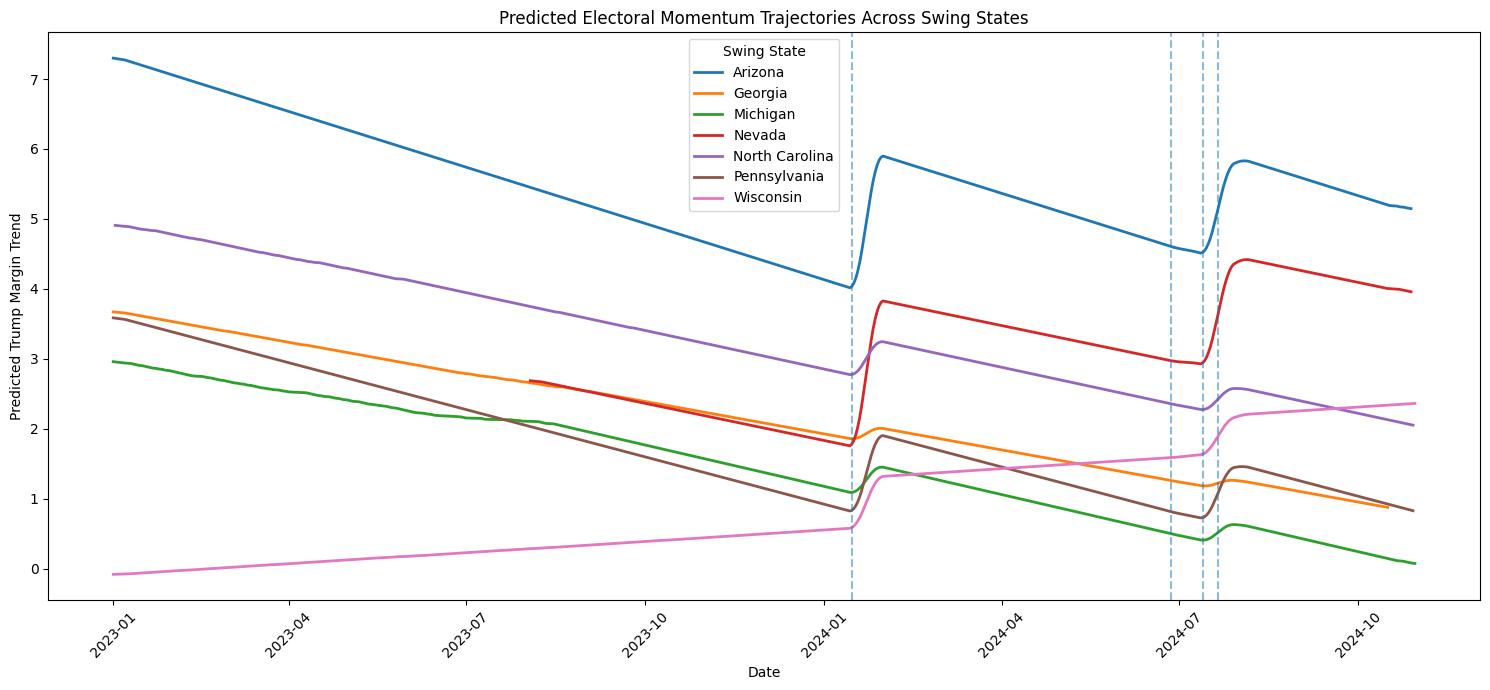

In [3]:
# ================================
# 10. LOAD FINAL ELECTION RESULTS
# ================================

results = pd.read_csv(
    r"E:\Csci_3\US_Election\Peilin\trump_vs_harris_margins.csv"
)

results.rename(columns={
    "trump_margin": "final_margin"
}, inplace=True)

results["state"] = results["state"].astype(str)

# ================================
# 11. BUILD STATE-LEVEL FEATURES
# ================================

did_cols = [f"{event}_did" for event in events.keys()]

state_features = daily.groupby("state").agg({
    "tweet_volume": "mean",
    "reply_volume": "mean",
    "log_volume": "mean",
    **{col: "sum" for col in did_cols}
}).reset_index()

# Engagement intensity
state_features["engagement_rate"] = (
    state_features["reply_volume"] /
    state_features["tweet_volume"]
)

# ================================
# 12. MERGE FINAL ELECTION OUTCOMES
# ================================

state_features = state_features.merge(
    results,
    on="state",
    how="left"
)

# IMPORTANT FIX:
# merge final election results into DAILY too
daily = daily.merge(
    results,
    on="state",
    how="left"
)

print("\n=== STATE FEATURES ===")
print(state_features)

# ================================
# 13. FINAL ELECTION PREDICTION MODEL
# ================================

formula = """
final_margin
~ engagement_rate
+ log_volume
+ campaign_start_did
+ debate_did
+ trump_incident_did
+ biden_dropout_did
"""

final_model = smf.ols(
    formula=formula,
    data=state_features
).fit()

print("\n=== FINAL ELECTION MODEL ===")
print(final_model.summary())

# ================================
# 14. GENERATE PREDICTIONS
# ================================

state_features["predicted_margin"] = (
    final_model.predict(state_features)
)

# Prediction error
state_features["prediction_error"] = (
    state_features["final_margin"] -
    state_features["predicted_margin"]
)

print("\n=== PREDICTIONS ===")
print(
    state_features[
        [
            "state",
            "final_margin",
            "predicted_margin",
            "prediction_error"
        ]
    ]
)

# ================================
# 15. DYNAMIC TRAJECTORY MODEL
# ================================

# Daily momentum proxy
daily["momentum"] = (
    daily["log_volume"]
    .diff()
)

# Remove NA from diff
daily = daily.dropna(subset=["momentum"]).copy()

# Trajectory model
trajectory_formula = """
momentum
~ campaign_start_did
+ debate_did
+ trump_incident_did
+ biden_dropout_did
+ C(state_id)
"""

trajectory_model = smf.ols(
    formula=trajectory_formula,
    data=daily
).fit()

print("\n=== DYNAMIC TRAJECTORY MODEL ===")
print(trajectory_model.summary())

# Predicted momentum
daily["predicted_momentum"] = (
    trajectory_model.predict(daily)
)

# ================================
# CONVERT MOMENTUM INTO TRAJECTORY
# ================================

daily = daily.sort_values(["state", "date"])

daily["trajectory"] = (
    daily.groupby("state")["predicted_momentum"]
    .cumsum()
)

# Smooth trajectories
daily["trajectory_smooth"] = (
    daily.groupby("state")["trajectory"]
    .transform(lambda x: x.rolling(7, min_periods=1).mean())
)

# ================================
# NORMALIZE TO FINAL MARGINS
# ================================

# Anchor trajectory endpoints
final_margin_map = dict(
    zip(results["state"], results["final_margin"])
)

for state in daily["state"].unique():

    mask = daily["state"] == state

    traj = daily.loc[mask, "trajectory_smooth"]

    if traj.std() == 0:
        continue

    # Standardize
    normalized = (
        (traj - traj.mean()) / traj.std()
    )

    # Scale around final election margin
    final_margin = final_margin_map.get(state, 0)

    daily.loc[mask, "trajectory_scaled"] = (
        normalized * 0.8 + final_margin
    )

# ================================
# VISUALIZATION
# ================================

plt.figure(figsize=(15, 7))

sns.lineplot(
    data=daily[daily["treated"] == 1],
    x="date",
    y="trajectory_scaled",
    hue="state",
    linewidth=2
)

# Event markers
for event_name, event_date in events.items():

    plt.axvline(
        pd.to_datetime(event_date, utc=True),
        linestyle="--",
        alpha=0.5
    )

plt.title(
    "Predicted Electoral Momentum Trajectories Across Swing States"
)

plt.xlabel("Date")
plt.ylabel("Predicted Trump Margin Trend")

plt.xticks(rotation=45)

plt.legend(title="Swing State")

plt.tight_layout()
plt.show()


=== ENGAGEMENT CONCENTRATION ===
                   state  total_volume  avg_volume  engagement_share
42                   USA        419259  626.695067          0.211285
3             California        285876  427.318386          0.144067
8                Florida        248889  373.146927          0.125427
31              New York        116417  174.016442          0.058668
41                 Texas        113635  170.623123          0.057266
29            New Jersey         75664  113.269461          0.038131
33                  Ohio         53905  134.092040          0.027165
47            Washington         50321   75.330838          0.025359
4               Colorado         49471   75.183891          0.024931
36          Pennsylvania         47840   71.616766          0.024109
9                Georgia         37679   58.965571          0.018988
27                Nevada         35652   79.403118          0.017967
46              Virginia         32341   48.706325          0.016298


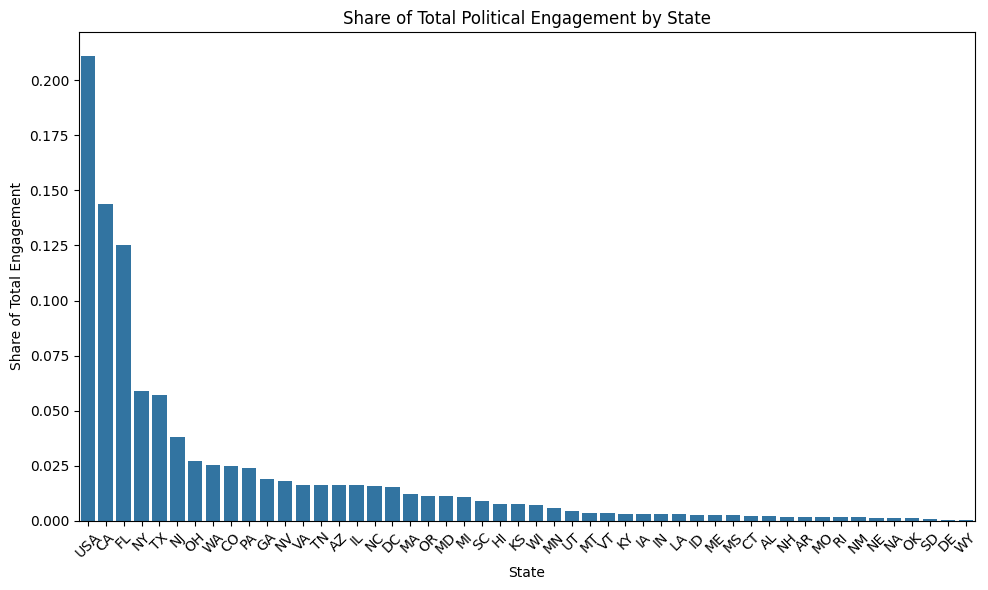

In [6]:
# ================================
# ENGAGEMENT CONCENTRATION TEST
# ================================

state_engagement = (
    daily.groupby("state")
    .agg(
        total_volume=("tweet_volume", "sum"),
        avg_volume=("tweet_volume", "mean")
    )
    .reset_index()
)

# Share of all engagement
total_all = state_engagement["total_volume"].sum()

state_engagement["engagement_share"] = (
    state_engagement["total_volume"] / total_all
)

print("\n=== ENGAGEMENT CONCENTRATION ===")
print(state_engagement.sort_values(
    "engagement_share",
    ascending=False
))

# ----------------------------
# State abbreviation mapping
# ----------------------------
state_abbrev = {
    "Alabama": "AL",
    "Alaska": "AK",
    "Arizona": "AZ",
    "Arkansas": "AR",
    "California": "CA",
    "Colorado": "CO",
    "Connecticut": "CT",
    "Delaware": "DE",
    "Florida": "FL",
    "Georgia": "GA",
    "Hawaii": "HI",
    "Idaho": "ID",
    "Illinois": "IL",
    "Indiana": "IN",
    "Iowa": "IA",
    "Kansas": "KS",
    "Kentucky": "KY",
    "Louisiana": "LA",
    "Maine": "ME",
    "Maryland": "MD",
    "Massachusetts": "MA",
    "Michigan": "MI",
    "Minnesota": "MN",
    "Mississippi": "MS",
    "Missouri": "MO",
    "Montana": "MT",
    "Nebraska": "NE",
    "Nevada": "NV",
    "New Hampshire": "NH",
    "New Jersey": "NJ",
    "New Mexico": "NM",
    "New York": "NY",
    "North Carolina": "NC",
    "North Dakota": "ND",
    "Ohio": "OH",
    "Oklahoma": "OK",
    "Oregon": "OR",
    "Pennsylvania": "PA",
    "Rhode Island": "RI",
    "South Carolina": "SC",
    "South Dakota": "SD",
    "Tennessee": "TN",
    "Texas": "TX",
    "Utah": "UT",
    "Vermont": "VT",
    "Virginia": "VA",
    "Washington": "WA",
    "West Virginia": "WV",
    "Wisconsin": "WI",
    "Wyoming": "WY",
    "District of Columbia": "DC",
    "Unknown": "NA"
}

# Apply abbreviation mapping
state_engagement["state_abbrev"] = state_engagement["state"].map(state_abbrev)

# Optional fallback (in case any state is missing)
state_engagement["state_abbrev"] = state_engagement["state_abbrev"].fillna(state_engagement["state"])

# ----------------------------
# Visualization
# ----------------------------

plt.figure(figsize=(10, 6))

sns.barplot(
    data=state_engagement.sort_values(
        "engagement_share",
        ascending=False
    ),
    x="state_abbrev",
    y="engagement_share"
)

plt.title("Share of Total Political Engagement by State")
plt.ylabel("Share of Total Engagement")
plt.xlabel("State")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


=== REPRESENTATION BIAS TEST ===
                   state  engagement_rate  predicted_margin  final_margin  \
0                Alabama         0.125536          5.885825           NaN   
1                Arizona         0.894404          4.067770           5.5   
2               Arkansas         0.960354         11.841360           NaN   
3             California         0.677594         16.394963           NaN   
4               Colorado         0.786097         13.482274           NaN   
5            Connecticut         0.999774         11.284577           NaN   
6               Delaware         1.000000          9.913224           NaN   
7   District of Columbia         0.682665         12.195773           NaN   
8                Florida         0.835051         19.166758           NaN   
9                Georgia         0.606969          1.440295           2.2   
10                Hawaii         0.602982         10.778308           NaN   
11                 Idaho         0.830615 

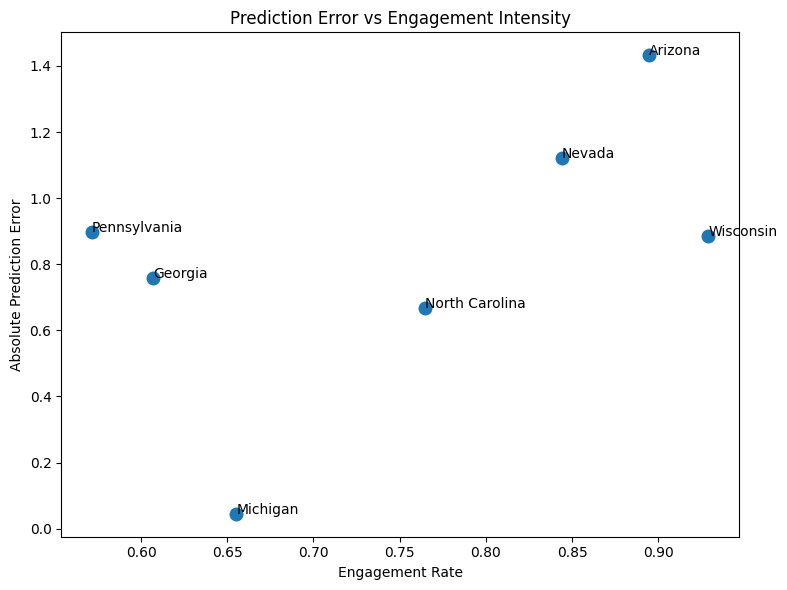

In [10]:
# ================================
# REPRESENTATION BIAS TEST
# ================================

state_features["absolute_error"] = (
    state_features["prediction_error"].abs()
)

print("\n=== REPRESENTATION BIAS TEST ===")

print(
    state_features[
        [
            "state",
            "engagement_rate",
            "predicted_margin",
            "final_margin",
            "absolute_error"
        ]
    ]
)

# Scatterplot

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=state_features,
    x="engagement_rate",
    y="absolute_error",
    s=120
)

for _, row in state_features.iterrows():
    plt.text(
        row["engagement_rate"],
        row["absolute_error"],
        row["state"]
    )

plt.title(
    "Prediction Error vs Engagement Intensity"
)

plt.xlabel("Engagement Rate")
plt.ylabel("Absolute Prediction Error")

plt.tight_layout()
plt.show()


=== VIRAL DAYS ===
                         date  tweet_volume
600 2024-08-23 00:00:00+00:00         13978
606 2024-08-29 00:00:00+00:00         14192
612 2024-09-04 00:00:00+00:00         14385
613 2024-09-05 00:00:00+00:00         15506
614 2024-09-06 00:00:00+00:00         16016
616 2024-09-08 00:00:00+00:00         14536
617 2024-09-09 00:00:00+00:00         16630
618 2024-09-10 00:00:00+00:00         16650
619 2024-09-11 00:00:00+00:00         23319
620 2024-09-12 00:00:00+00:00         18295
621 2024-09-13 00:00:00+00:00         17539
622 2024-09-14 00:00:00+00:00         16341
623 2024-09-15 00:00:00+00:00         17939
624 2024-09-16 00:00:00+00:00         19506
625 2024-09-17 00:00:00+00:00         22441
626 2024-09-18 00:00:00+00:00         20873
627 2024-09-19 00:00:00+00:00         22415
628 2024-09-20 00:00:00+00:00         16225
630 2024-09-22 00:00:00+00:00         15545
631 2024-09-23 00:00:00+00:00         15217
632 2024-09-24 00:00:00+00:00         16709
633 2024-09-

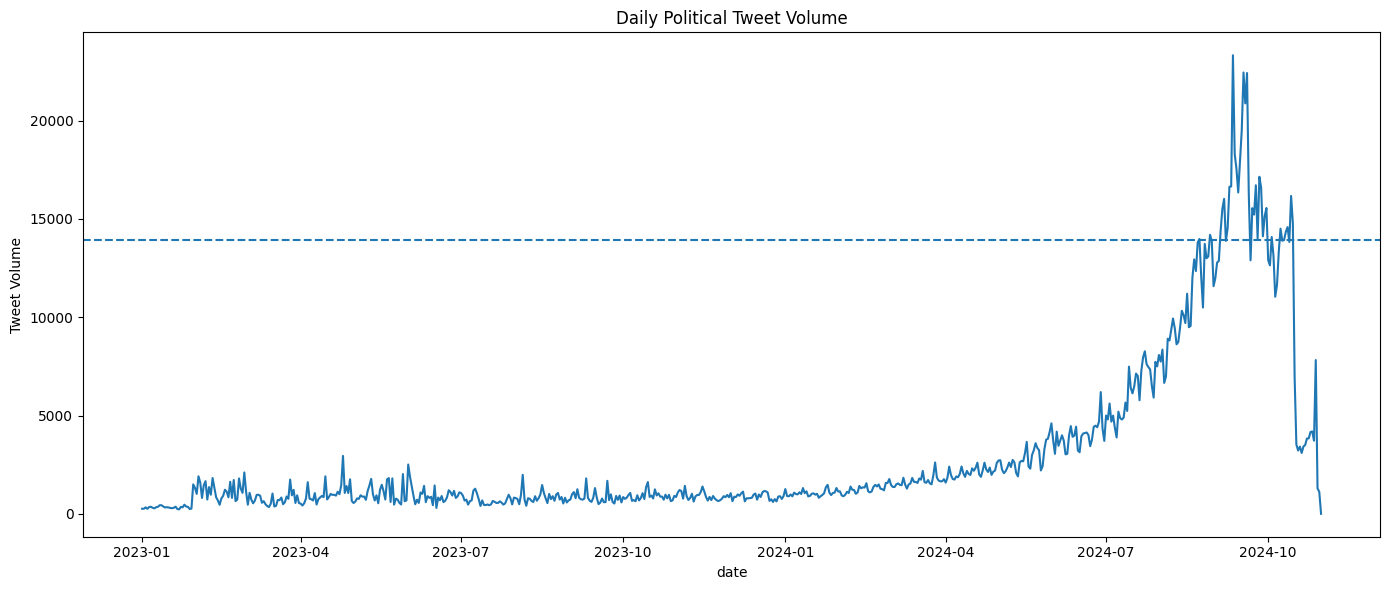

In [8]:
# ================================
# VIRAL SPIKE INEQUALITY TEST
# ================================

daily_total = (
    daily.groupby("date")["tweet_volume"]
    .sum()
    .reset_index()
)

threshold = daily_total["tweet_volume"].quantile(0.95)

viral_days = daily_total[
    daily_total["tweet_volume"] >= threshold
]

print("\n=== VIRAL DAYS ===")
print(viral_days)

# Visualization

plt.figure(figsize=(14,6))

sns.lineplot(
    data=daily_total,
    x="date",
    y="tweet_volume"
)

plt.axhline(
    threshold,
    linestyle="--"
)

plt.title("Daily Political Tweet Volume")
plt.ylabel("Tweet Volume")

plt.tight_layout()
plt.show()

In [7]:
# ================================
# MISSINGNESS AUDIT
# ================================

missing_by_state = (
    daily.groupby("state")
    .apply(lambda x: x.isna().mean())
)

print("\n=== MISSINGNESS BY STATE ===")
print(missing_by_state)

# Missing dates

date_counts = (
    daily.groupby("state")["date"]
    .nunique()
    .reset_index(name="observed_days")
)

print("\n=== OBSERVED DAYS ===")
print(date_counts)


=== MISSINGNESS BY STATE ===
                      state  date  tweet_volume  reply_volume  treated  \
state                                                                    
Alabama                 0.0   0.0           0.0           0.0      0.0   
Arizona                 0.0   0.0           0.0           0.0      0.0   
Arkansas                0.0   0.0           0.0           0.0      0.0   
California              0.0   0.0           0.0           0.0      0.0   
Colorado                0.0   0.0           0.0           0.0      0.0   
Connecticut             0.0   0.0           0.0           0.0      0.0   
Delaware                0.0   0.0           0.0           0.0      0.0   
District of Columbia    0.0   0.0           0.0           0.0      0.0   
Florida                 0.0   0.0           0.0           0.0      0.0   
Georgia                 0.0   0.0           0.0           0.0      0.0   
Hawaii                  0.0   0.0           0.0           0.0      0.0   
Idaho   

C:\Users\19241\AppData\Local\Temp\ipykernel_11828\3845960362.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.isna().mean())
